## Import Necessary Modules

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../src/models')

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import T5Tokenizer, T5ForConditionalGeneration

from generation import (
    T5GenerationOnlyModel,
    TextOnlyDataset,
    create_temperature_input,
    compute_rougeL,
    train_and_validate_t5_with_metrics,
    train_and_validate_t5_with_early_stopping,
    evaluate_on_test_set,
    plot_training_metrics
)


## Set Random Seed, For Reproducibility

In [2]:
# For reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Dataset

In [3]:
mwr_df_simple = pd.read_csv('mwr_simple.csv')

## Extract Features

In [4]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_simple.columns if col.endswith('int') or col.endswith('sk')]

# Prepare text targets (binary classification)
mwr_df_simple['synthetic_description'] = mwr_df_simple['Synthetic_Conclusion']

## Split into Training, Validation and Test Splits

In [5]:
train_simple_df, temp_simple_df = train_test_split(
    mwr_df_simple, 
    test_size=0.3, 
    random_state=42
)
val_simple_df, test_simple_df = train_test_split(
    temp_simple_df, 
    test_size=0.5, 
    random_state=42
)

In [7]:
train_dataset = TextOnlyDataset(train_simple_df, tokenizer)
val_dataset = TextOnlyDataset(val_simple_df, tokenizer)
test_dataset = TextOnlyDataset(test_simple_df, tokenizer)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Initialise Model

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize tokenizer (you might have already done this)
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Initialize model (your custom model or directly from transformers)
model = T5GenerationOnlyModel(model_name='t5-small')
model.to(device)

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

## 30 epochs

### Train Model


Epoch 1/30


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:54<00:00,  1.80it/s, loss=0.0366]


Training loss: 0.6118
Validation loss: 0.0278

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.3601
  ROUGE-L Score: 0.5287
  ✓ New best METEOR: 0.3601
  ✓ New best ROUGE-L: 0.5287

Epoch 2/30


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:57<00:00,  1.79it/s, loss=0.0482]


Training loss: 0.0357
Validation loss: 0.0240

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4154
  ROUGE-L Score: 0.5465
  ✓ New best METEOR: 0.4154
  ✓ New best ROUGE-L: 0.5465

Epoch 3/30


...

Training loss: 0.0224
Validation loss: 0.0211

--- Text Generation Evaluation (Epoch 28) ---
  METEOR Score : 0.4830
  ROUGE-L Score: 0.5731

Epoch 29/30


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:56<00:00,  1.79it/s, loss=0.0164]


Training loss: 0.0222
Validation loss: 0.0213

--- Text Generation Evaluation (Epoch 29) ---
  METEOR Score : 0.4747
  ROUGE-L Score: 0.5604

Epoch 30/30


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:55<00:00,  1.80it/s, loss=0.0198]


Training loss: 0.0220
Validation loss: 0.0212

--- Text Generation Evaluation (Epoch 30) ---
  METEOR Score : 0.4860
  ROUGE-L Score: 0.5702


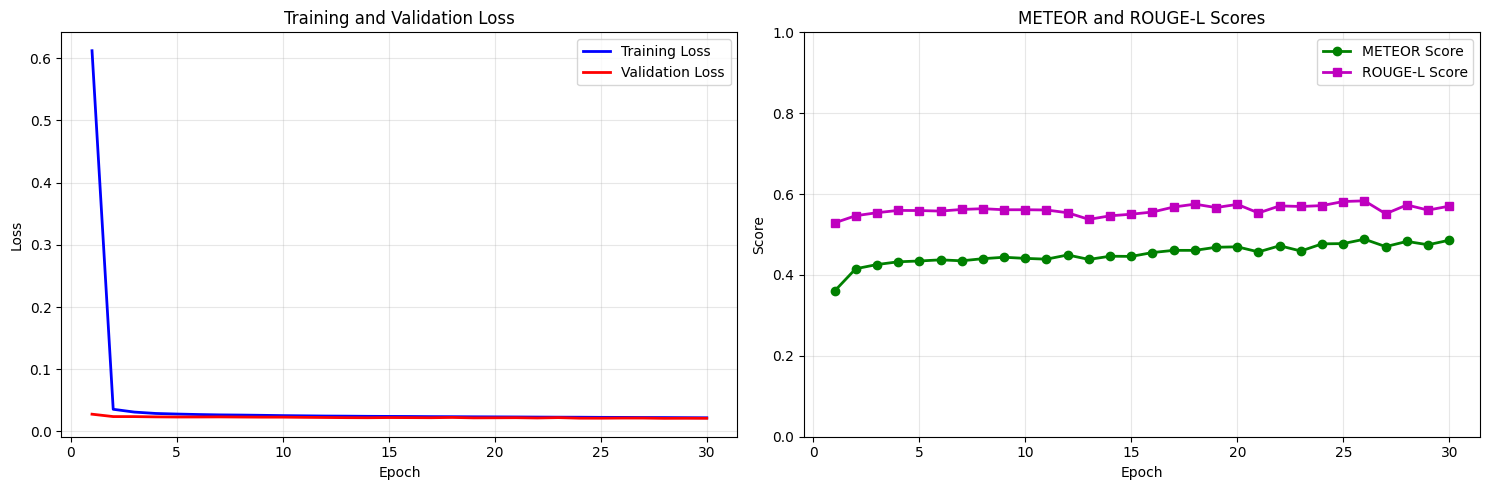


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0220
Final Validation Loss: 0.0212
Final METEOR Score: 0.4860
Best METEOR Score: 0.4884
Final ROUGE-L Score: 0.5702
Best ROUGE-L Score: 0.5833


In [9]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss = train_and_validate_t5_with_metrics(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    num_epochs=30,
    meteor_every=1
)

### Test Model

In [10]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)
# no early stopping

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0219
  METEOR Score: 0.4699
  ROUGE-L Score: 0.5639

Sample Predictions:
------------------------------
Example 1:
  Reference: Slightly elevated temperature.
  Prediction: No thermal changes detected.
  METEOR: 0.0000

Example 2:
  Reference: Increased temperature (surface and depth), partial asymmetry.
  Prediction: Increased temperature (surface and depth), greater and clear asymmetry.
  METEOR: 0.7099

Example 3:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 4:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Increased temperature (surface and depth), greater and clear asymmetry.
  METEOR: 0.4056

Example 5:
  Reference: Moderately elevated temperature (surface).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.9922



## 50 epochs

### Train Model


Epoch 1/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:11<00:00,  4.03it/s, loss=0.0345]


Training loss: 0.6078
Validation loss: 0.0276

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.3584
  ROUGE-L Score: 0.5120
  ✓ New best METEOR: 0.3584
  ✓ New best ROUGE-L: 0.5120

Epoch 2/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:30<00:00,  3.52it/s, loss=0.0339]


Training loss: 0.0357
Validation loss: 0.0239

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4125
  ROUGE-L Score: 0.5155
  ✓ New best METEOR: 0.4125
  ✓ New best ROUGE-L: 0.5155

Epoch 3/50


...

Training loss: 0.0204
Validation loss: 0.0213

--- Text Generation Evaluation (Epoch 48) ---
  METEOR Score : 0.4877
  ROUGE-L Score: 0.5756

Epoch 49/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:14<00:00,  3.95it/s, loss=0.0264]


Training loss: 0.0204
Validation loss: 0.0210

--- Text Generation Evaluation (Epoch 49) ---
  METEOR Score : 0.4870
  ROUGE-L Score: 0.5627

Epoch 50/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:40<00:00,  3.32it/s, loss=0.0242]


Training loss: 0.0203
Validation loss: 0.0208

--- Text Generation Evaluation (Epoch 50) ---
  METEOR Score : 0.4968
  ROUGE-L Score: 0.5880


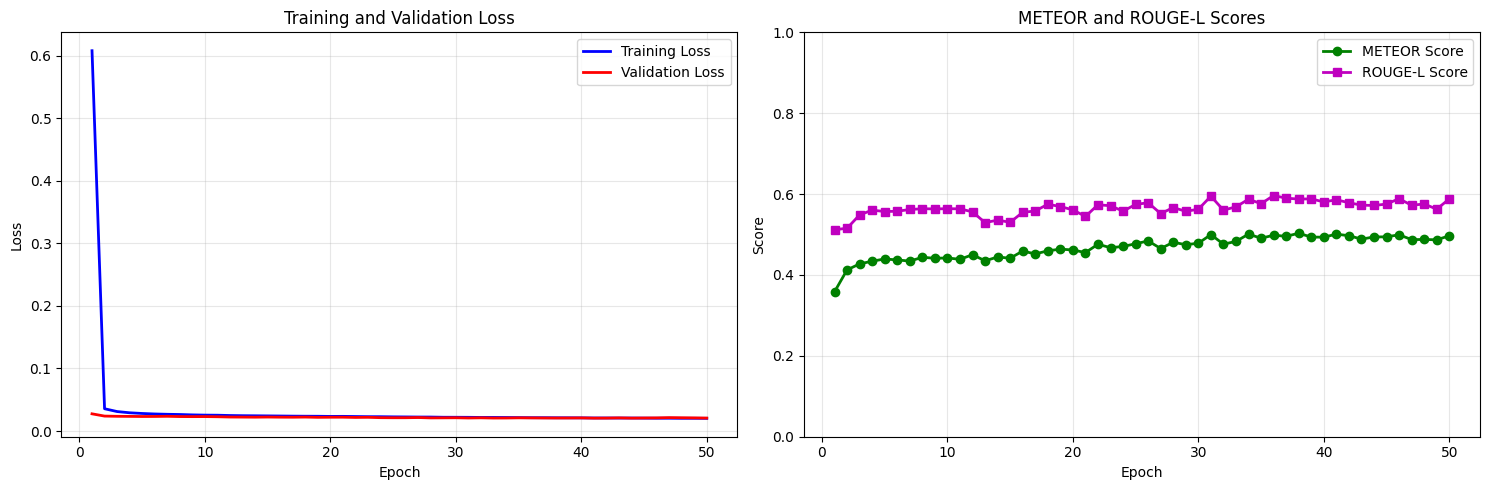


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0203
Final Validation Loss: 0.0208
Final METEOR Score: 0.4968
Best METEOR Score: 0.5031
Final ROUGE-L Score: 0.5880
Best ROUGE-L Score: 0.5965


In [9]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss = train_and_validate_t5_with_metrics(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    num_epochs=50,
    meteor_every=1
)

### Test Model

In [10]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0214
  METEOR Score: 0.4991
  ROUGE-L Score: 0.5998

Sample Predictions:
------------------------------
Example 1:
  Reference: Slightly elevated temperature.
  Prediction: No thermal changes detected.
  METEOR: 0.0000

Example 2:
  Reference: Increased temperature (surface and depth), partial asymmetry.
  Prediction: Increased temperature (surface and depth), greater and clear asymmetry.
  METEOR: 0.7099

Example 3:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 4:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 5:
  Reference: Moderately elevated temperature (surface).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.9922



## Early Stopping, Patience 5

### Train Model

Early stopping enabled: patience=5, min_delta=0.001

Epoch 1/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [05:03<00:00,  1.75it/s, loss=0.0216]


Training loss: 0.6641
Validation loss: 0.0311
✓ New best validation loss: 0.0311

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.3603
  ROUGE-L Score: 0.5292
  ✓ New best METEOR: 0.3603
  ✓ New best ROUGE-L: 0.5292

Epoch 2/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:59<00:00,  1.77it/s, loss=0.0419]


Training loss: 0.0361
Validation loss: 0.0243
✓ New best validation loss: 0.0243

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4295
  ROUGE-L Score: 0.5426
  ✓ New best METEOR: 0.4295
  ✓ New best ROUGE-L: 0.5426

Epoch 3/50


...

Training loss: 0.0259
Validation loss: 0.0232
No improvement in validation loss. Patience: 3/5

--- Text Generation Evaluation (Epoch 9) ---
  METEOR Score : 0.4333
  ROUGE-L Score: 0.5366

Epoch 10/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [05:03<00:00,  1.75it/s, loss=0.0231]


Training loss: 0.0256
Validation loss: 0.0230
No improvement in validation loss. Patience: 4/5

--- Text Generation Evaluation (Epoch 10) ---
  METEOR Score : 0.4433
  ROUGE-L Score: 0.5638
  ✓ New best METEOR: 0.4433
  ✓ New best ROUGE-L: 0.5638

Epoch 11/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:59<00:00,  1.77it/s, loss=0.0158]


Training loss: 0.0255
Validation loss: 0.0230
No improvement in validation loss. Patience: 5/5

Early stopping triggered after 11 epochs!
Best validation loss: 0.0231

Loaded best model with validation loss: 0.0231
Best model saved to: best_model.pt


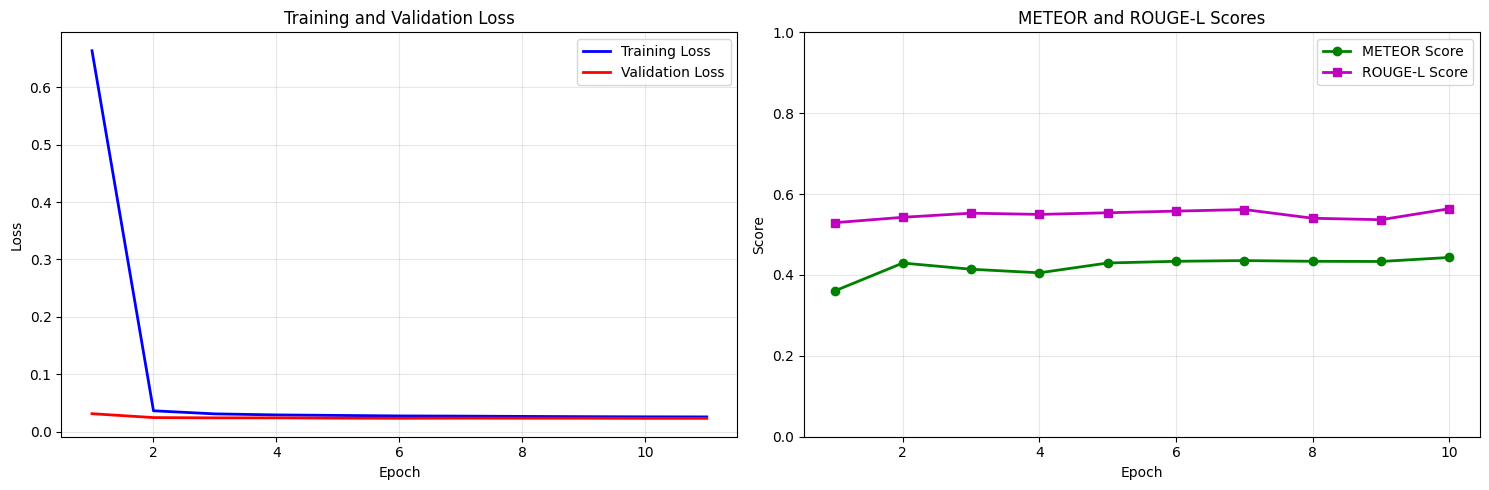


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0255
Final Validation Loss: 0.0230
Final METEOR Score: 0.4433
Best METEOR Score: 0.4433
Final ROUGE-L Score: 0.5638
Best ROUGE-L Score: 0.5638


(0.4432893063132213,
 0.5637776254007417,
 0.025469385782035732,
 0.02295687307783386,
 0.023076062025338934)

In [20]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss, best_val_loss = train_and_validate_t5_with_early_stopping(
    model, train_loader, val_loader, optimizer,
    device, tokenizer, num_epochs=50, meteor_every=1,
    patience=5, min_delta=0.001, save_best_model=True, model_save_path="best_model.pt"
)

### Test Model

In [21]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0235
  METEOR Score: 0.4351
  ROUGE-L Score: 0.5660

Sample Predictions:
------------------------------
Example 1:
  Reference: Slightly elevated temperature.
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.1613

Example 2:
  Reference: Increased temperature (surface and depth), partial asymmetry.
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.0746

Example 3:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 4:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 5:
  Reference: Moderately elevated temperature (surface).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.9922



# Early Stopping, Patience 10

### Train Model

Early stopping enabled: patience=10, min_delta=0.001

Epoch 1/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [04:59<00:00,  1.78it/s, loss=0.0368]


Training loss: 0.5971
Validation loss: 0.0274
✓ New best validation loss: 0.0274

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.3603
  ROUGE-L Score: 0.5294
  ✓ New best METEOR: 0.3603
  ✓ New best ROUGE-L: 0.5294

Epoch 2/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [05:00<00:00,  1.77it/s, loss=0.0195]


Training loss: 0.0354
Validation loss: 0.0241
✓ New best validation loss: 0.0241

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4244
  ROUGE-L Score: 0.5535
  ✓ New best METEOR: 0.4244
  ✓ New best ROUGE-L: 0.5535

Epoch 3/50


...

Training loss: 0.0242
Validation loss: 0.0224
No improvement in validation loss. Patience: 8/10

--- Text Generation Evaluation (Epoch 16) ---
  METEOR Score : 0.4522
  ROUGE-L Score: 0.5639
  ✓ New best METEOR: 0.4522
  ✓ New best ROUGE-L: 0.5639

Epoch 17/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [05:00<00:00,  1.77it/s, loss=0.0276]


Training loss: 0.0240
Validation loss: 0.0220
No improvement in validation loss. Patience: 9/10

--- Text Generation Evaluation (Epoch 17) ---
  METEOR Score : 0.4442
  ROUGE-L Score: 0.5360

Epoch 18/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [05:02<00:00,  1.75it/s, loss=0.0299]


Training loss: 0.0238
Validation loss: 0.0221
No improvement in validation loss. Patience: 10/10

Early stopping triggered after 18 epochs!
Best validation loss: 0.0230

Loaded best model with validation loss: 0.0230
Best model saved to: best_model.pt


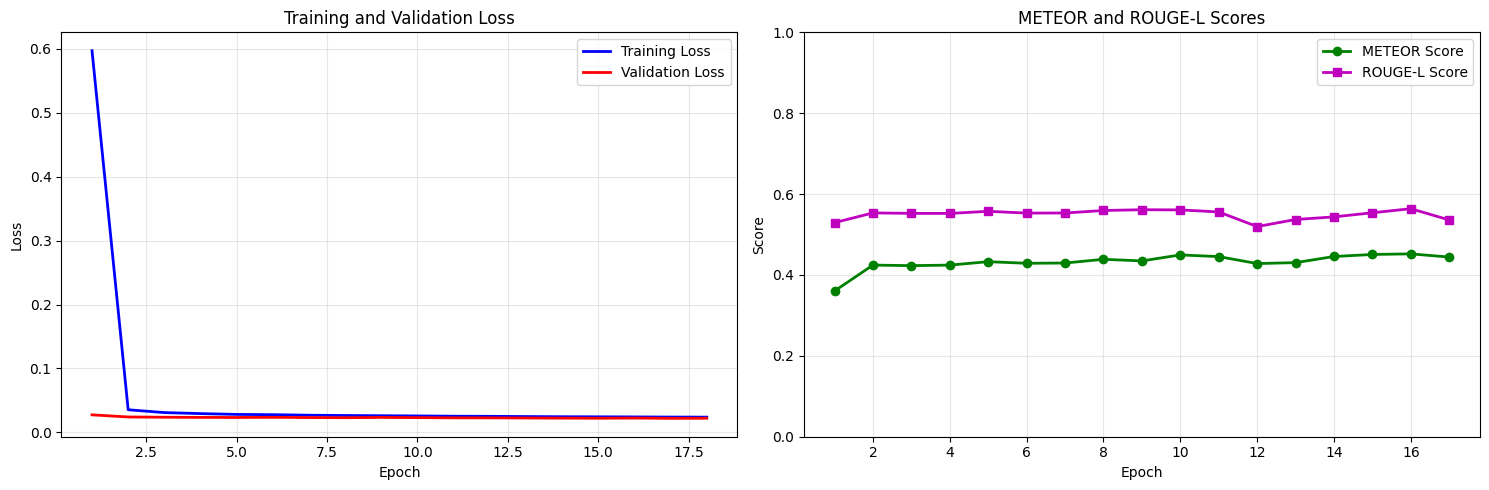


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0238
Final Validation Loss: 0.0221
Final METEOR Score: 0.4442
Best METEOR Score: 0.4522
Final ROUGE-L Score: 0.5360
Best ROUGE-L Score: 0.5639


In [26]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss, best_val_loss = train_and_validate_t5_with_early_stopping(
    model, train_loader, val_loader, optimizer,
    device, tokenizer, num_epochs=50, meteor_every=1,
    patience=10, min_delta=0.001, save_best_model=True, model_save_path="best_model.pt"
)

### Test Model

In [27]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0227
  METEOR Score: 0.4479
  ROUGE-L Score: 0.5439

Sample Predictions:
------------------------------
Example 1:
  Reference: Slightly elevated temperature.
  Prediction: No thermal changes detected.
  METEOR: 0.0000

Example 2:
  Reference: Increased temperature (surface and depth), partial asymmetry.
  Prediction: Increased temperature (surface and depth), greater and clear asymmetry.
  METEOR: 0.7099

Example 3:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 4:
  Reference: Moderately elevated temperature (surface and depth).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.5077

Example 5:
  Reference: Moderately elevated temperature (surface).
  Prediction: Moderately elevated temperature (surface).
  METEOR: 0.9922



## Temperature Based Descriptions

### Load Dataset

In [11]:
mwr_df_temps = pd.read_csv('mwr_temps.csv')

In [12]:
print(mwr_df_temps.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'Synthetic_Conclusion', 'y_binary'],
      dtype='object')


### Extract Features

In [13]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_temps if col.endswith('int') or col.endswith('sk')]

# Prepare text targets (binary classification)
mwr_df_temps['synthetic_description'] = mwr_df_temps['Synthetic_Conclusion']

### Split into Training, Validation and Test Splits

In [14]:
train_df_temps, temp_df_temps = train_test_split(
    mwr_df_temps, 
    test_size=0.3, 
    random_state=42
)
val_df_temps, test_df_temps = train_test_split(
    temp_df_temps, 
    test_size=0.5, 
    random_state=42
)

In [15]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [17]:
train_dataset = TextOnlyDataset(train_df_temps, tokenizer)
val_dataset = TextOnlyDataset(val_df_temps, tokenizer)
test_dataset = TextOnlyDataset(test_df_temps, tokenizer)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Initialise Model

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize tokenizer (you might have already done this)
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Initialize model (your custom model or directly from transformers)
model = T5GenerationOnlyModel(model_name='t5-small')
model.to(device)

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

### Train Model


Epoch 1/50


Training: 100%|███████████████████████████████████████████████████████████| 531/531 [02:39<00:00,  3.33it/s, loss=0.139]


Training loss: 0.7946
Validation loss: 0.0602

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.3885
  ROUGE-L Score: 0.4321
  ✓ New best METEOR: 0.3885
  ✓ New best ROUGE-L: 0.4321

Epoch 2/50


Training: 100%|███████████████████████████████████████████████████████████| 531/531 [02:17<00:00,  3.86it/s, loss=0.113]


Training loss: 0.0704
Validation loss: 0.0469

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.3681
  ROUGE-L Score: 0.4085

Epoch 3/50


...

Training loss: 0.0333
Validation loss: 0.0342

--- Text Generation Evaluation (Epoch 48) ---
  METEOR Score : 0.5007
  ROUGE-L Score: 0.5268

Epoch 49/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:20<00:00,  3.77it/s, loss=0.0342]


Training loss: 0.0333
Validation loss: 0.0341

--- Text Generation Evaluation (Epoch 49) ---
  METEOR Score : 0.4917
  ROUGE-L Score: 0.5141

Epoch 50/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:20<00:00,  3.78it/s, loss=0.0215]


Training loss: 0.0330
Validation loss: 0.0348

--- Text Generation Evaluation (Epoch 50) ---
  METEOR Score : 0.4865
  ROUGE-L Score: 0.5056


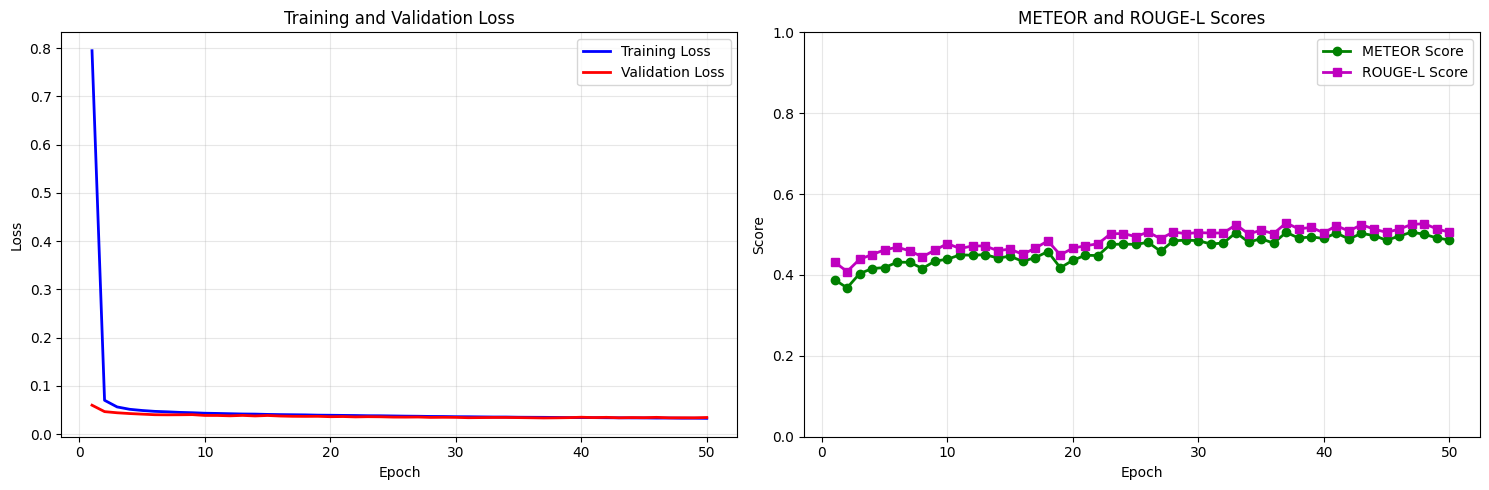


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0330
Final Validation Loss: 0.0348
Final METEOR Score: 0.4865
Best METEOR Score: 0.5058
Final ROUGE-L Score: 0.5056
Best ROUGE-L Score: 0.5287


In [22]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss = train_and_validate_t5_with_metrics(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    num_epochs=50,
    meteor_every=1
)

### Test Model

In [23]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0347
  METEOR Score: 0.4819
  ROUGE-L Score: 0.5044

Sample Predictions:
------------------------------
Example 1:
  Reference: Very mild regional irregularities observed. Slight internal surface disparity.
  Prediction: No thermal changes detected.
  METEOR: 0.0000

Example 2:
  Reference: Significant thermal irregularities observed. Marked asymmetry between left and right breast. Deep tissue activity likely.
  Prediction: Significant thermal irregularities observed. Marked asymmetry between left and right breast. Deep tissue activity likely.
  METEOR: 0.9999

Example 3:
  Reference: Moderate thermal deviations detected.
  Prediction: Low-grade thermal anomalies present. Internal temperatures elevated relative to surface.
  METEOR: 0.1087

Example 4:
  Reference: Moderate thermal deviations detected.
  Prediction: Significant thermal irregularities observed. Deep tissue activity likely.
  METEOR: 0.1136


## Advanced Descriptions

### Load Dataset

In [4]:
mwr_df_adv = pd.read_csv('mwr_adv.csv')

### Extract Features

In [5]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df_adv.columns if col.endswith('int') or col.endswith('sk')]

# Prepare text targets (binary classification)
mwr_df_adv['synthetic_description'] = mwr_df_adv['Enhanced_Synthetic_Conclusion']

### Split into Training, Validation and Test Splits

In [6]:
train_adv_df, temp_adv_df = train_test_split(
    mwr_df_adv, 
    test_size=0.3, 
    random_state=42
)
val_adv_df, test_adv_df = train_test_split(
    temp_adv_df, 
    test_size=0.5, 
    random_state=42
)

In [7]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [8]:
train_dataset = TextOnlyDataset(train_adv_df, tokenizer)
val_dataset = TextOnlyDataset(val_adv_df, tokenizer)
test_dataset = TextOnlyDataset(test_adv_df, tokenizer)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Initialise Model

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize tokenizer (you might have already done this)
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Initialize model (your custom model or directly from transformers)
model = T5GenerationOnlyModel(model_name='t5-small')
model.to(device)

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

### Train Model


Epoch 1/50


Training: 100%|███████████████████████████████████████████████████████████| 531/531 [02:51<00:00,  3.09it/s, loss=0.074]


Training loss: 0.8989
Validation loss: 0.0836

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.4200
  ROUGE-L Score: 0.4956
  ✓ New best METEOR: 0.4200
  ✓ New best ROUGE-L: 0.4956

Epoch 2/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:52<00:00,  3.07it/s, loss=0.0999]


Training loss: 0.1097
Validation loss: 0.0392

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4230
  ROUGE-L Score: 0.5043
  ✓ New best METEOR: 0.4230
  ✓ New best ROUGE-L: 0.5043

Epoch 3/50


...

Training loss: 0.0255
Validation loss: 0.0252

--- Text Generation Evaluation (Epoch 48) ---
  METEOR Score : 0.5084
  ROUGE-L Score: 0.5627

Epoch 49/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:52<00:00,  3.09it/s, loss=0.0296]


Training loss: 0.0255
Validation loss: 0.0252

--- Text Generation Evaluation (Epoch 49) ---
  METEOR Score : 0.5012
  ROUGE-L Score: 0.5479

Epoch 50/50


Training: 100%|██████████████████████████████████████████████████████████| 531/531 [02:52<00:00,  3.08it/s, loss=0.0267]


Training loss: 0.0254
Validation loss: 0.0250

--- Text Generation Evaluation (Epoch 50) ---
  METEOR Score : 0.5037
  ROUGE-L Score: 0.5546


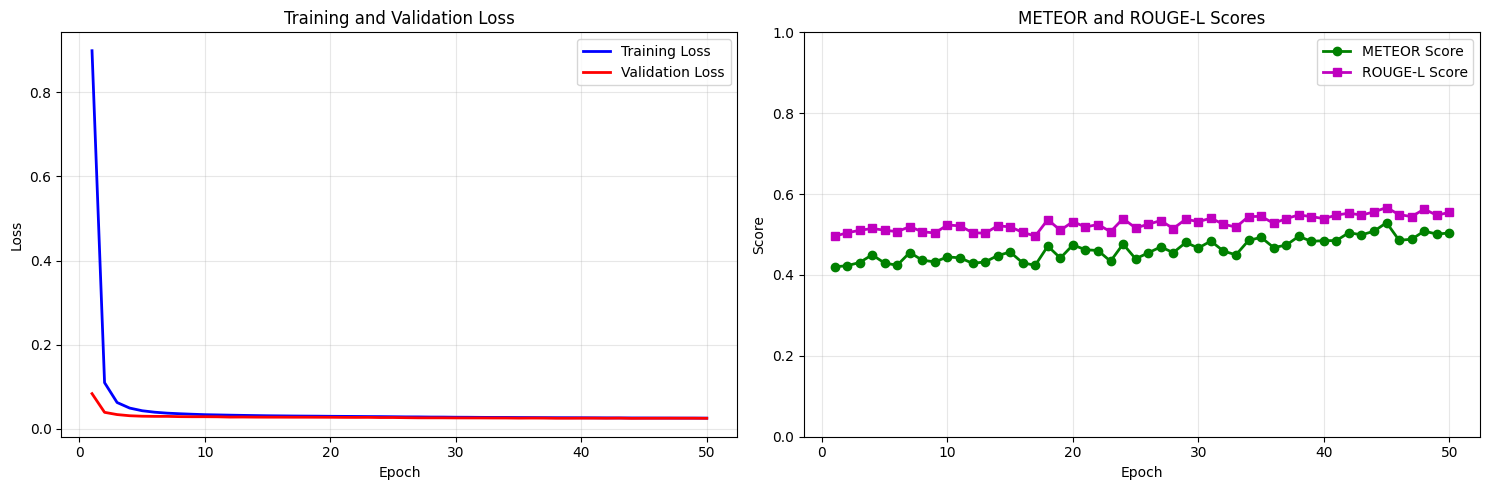


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.0254
Final Validation Loss: 0.0250
Final METEOR Score: 0.5037
Best METEOR Score: 0.5294
Final ROUGE-L Score: 0.5546
Best ROUGE-L Score: 0.5667


In [10]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss = train_and_validate_t5_with_metrics(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    num_epochs=50,
    meteor_every=1
)

### Test Model

In [11]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3636
  Test Loss: 0.0250
  METEOR Score: 0.5013
  ROUGE-L Score: 0.5524

Sample Predictions:
------------------------------
Example 1:
  Reference: The temperature in both breasts is well distributed with minor variations from the average. I advise regular self-examinations and a re-measurement in one year.
  Prediction: The temperature in both breasts is symmetrically distributed and within normal limits. The difference between deep and superficial values indicates normal tissue metabolism. There are no signs of local hyperthermia or abnormal thermal activity. I advise regular self-examination of the breasts once a month and a systematic
  METEOR: 0.4353

Example 2:
  Reference: The measured temperature demonstrates significant asymmetry and elevation. The left breast shows markedly increased thermal activity. I advise a clinical examination by a specialized physician and possibly further treatment. In case of any palpable 

## Real Data

### Load Dataset

In [3]:
mwr_df = pd.read_csv('mwr.csv')

### Extract Features

In [4]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df if col.endswith('int') or col.endswith('sk')]

# Prepare text targets (binary classification)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split into Training, Test and Validation Splits

In [5]:
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42
)

In [6]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [7]:
train_dataset = TextOnlyDataset(train_df, tokenizer)
val_dataset = TextOnlyDataset(val_df, tokenizer)
test_dataset = TextOnlyDataset(test_df, tokenizer)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Initialise Model

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize tokenizer (you might have already done this)
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# Initialize model (your custom model or directly from transformers)
model = T5GenerationOnlyModel(model_name='t5-small')
model.to(device)

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

### Train Model


Epoch 1/50


Training: 100%|███████████████████████████████████████████████████████████| 529/529 [02:47<00:00,  3.16it/s, loss=0.798]


Training loss: 1.5295
Validation loss: 0.7200

--- Text Generation Evaluation (Epoch 1) ---
  METEOR Score : 0.4072
  ROUGE-L Score: 0.4420
  ✓ New best METEOR: 0.4072
  ✓ New best ROUGE-L: 0.4420

Epoch 2/50


Training: 100%|███████████████████████████████████████████████████████████| 529/529 [02:53<00:00,  3.04it/s, loss=0.544]


Training loss: 0.7641
Validation loss: 0.5862

--- Text Generation Evaluation (Epoch 2) ---
  METEOR Score : 0.4186
  ROUGE-L Score: 0.4365
  ✓ New best METEOR: 0.4186

Epoch 3/50


...

Training loss: 0.3687
Validation loss: 0.3600

--- Text Generation Evaluation (Epoch 48) ---
  METEOR Score : 0.3891
  ROUGE-L Score: 0.4176

Epoch 49/50


Training: 100%|███████████████████████████████████████████████████████████| 529/529 [02:52<00:00,  3.06it/s, loss=0.401]


Training loss: 0.3678
Validation loss: 0.3594

--- Text Generation Evaluation (Epoch 49) ---
  METEOR Score : 0.3582
  ROUGE-L Score: 0.3907

Epoch 50/50


Training: 100%|███████████████████████████████████████████████████████████| 529/529 [02:54<00:00,  3.03it/s, loss=0.453]


Training loss: 0.3660
Validation loss: 0.3589

--- Text Generation Evaluation (Epoch 50) ---
  METEOR Score : 0.3744
  ROUGE-L Score: 0.4029


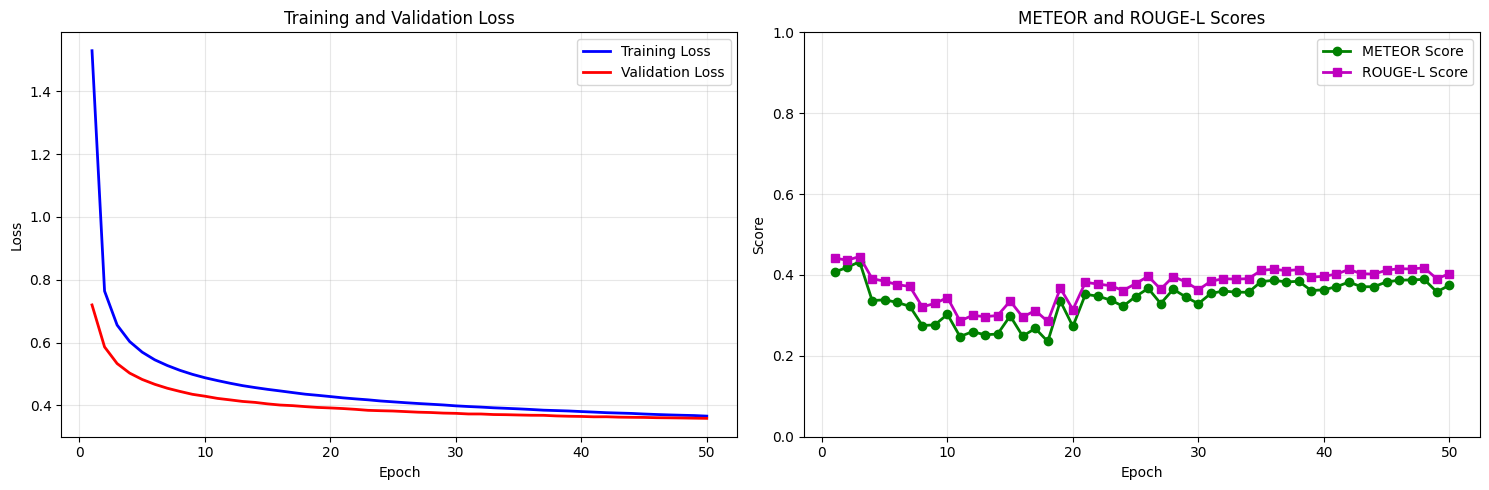


TRAINING COMPLETED - FINAL METRICS SUMMARY
Final Training Loss: 0.3660
Final Validation Loss: 0.3589
Final METEOR Score: 0.3744
Best METEOR Score: 0.4328
Final ROUGE-L Score: 0.4029
Best ROUGE-L Score: 0.4456


In [9]:
best_meteor, best_rougeL, avg_train_loss, avg_val_loss = train_and_validate_t5_with_metrics(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    num_epochs=50,
    meteor_every=1
)

### Test Model

In [10]:
test_results = evaluate_on_test_set(model, test_loader, device, tokenizer)

EVALUATING ON TEST SET
Test Set Results:
  Samples evaluated: 3625
  Test Loss: 0.3592
  METEOR Score: 0.3667
  ROUGE-L Score: 0.3945

Sample Predictions:
------------------------------
Example 1:
  Reference: The measured temperature values are exceeded on the surface. It is observed that the entire left breast is cooler, but the current values do not indicate signs of locally higher metabolism in the breast tissue.
  Prediction: The measured temperature is asymmetrically distributed, currently above the recommended value, therefore we recommend repeating the measurement in 3-4 months (05-06.2013). During this period, we advise the lady to perform self-examinations and to schedule a preventive mammogram (last one
  METEOR: 0.1795

Example 2:
  Reference: The measured temperature does not indicate signs of locally increased metabolism in breast tissue. We recommend the next check in 1 year (June 2014). During this period, the lady will perform self-examinations and schedule a mammogram